In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt

import sys
import os
DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
folders = [DIR+"/modules/", DIR+ "/dataset/", DIR+"/benchmarking/"]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)

import torch
import torch.optim as optim

import matplotlib.pyplot as plt

from funcshape.surface import PointCloudSurface
from funcshape.transforms import SRNF
from funcshape.visual import plot_surface
    
from funcshape.networks import SurfaceReparametrizer
from funcshape.layers.sinefourier import SineFourierLayer
from funcshape.loss import SurfaceDistance
from funcshape.reparametrize import reparametrize
from funcshape.logging import Logger 
from funcshape.interpolation import linear_interpolate
from sklearn.neighbors import KDTree
from collections import defaultdict

In [34]:
def find_boundary_points(points, labels, k=10):
    """
    Identify boundary points in a point cloud with labels using KDTree.
    
    Parameters
    ----------
    points : ndarray of shape (N, 3)
        3D coordinates of points
    labels : ndarray of shape (N,)
        Class labels (e.g. +1/-1 or multiclass)
    k : int
        Number of neighbors to check for label differences
    
    Returns
    -------
    boundaries : dict
        Dictionary where keys are (label_a, label_b) tuples and values 
        are arrays of boundary points lying between those classes.
    """
    tree = KDTree(points)
    boundaries = defaultdict(list)

    for i, p in enumerate(points):
        _, idx = tree.query([p], k=k)
        neighbor_labels = labels[idx[0]]
        
        # Compare with current point’s label
        current_label = labels[i]
        diff_labels = set(neighbor_labels) - {current_label}
        
        for other_label in diff_labels:
            key = tuple(sorted((current_label.item(), other_label.item())))
            boundaries[key].append(p)

    # Convert lists to numpy arrays
    return {k: np.array(v) for k, v in boundaries.items()}

Boundary (0, 1): 951 points
Boundary (1, 2): 720 points


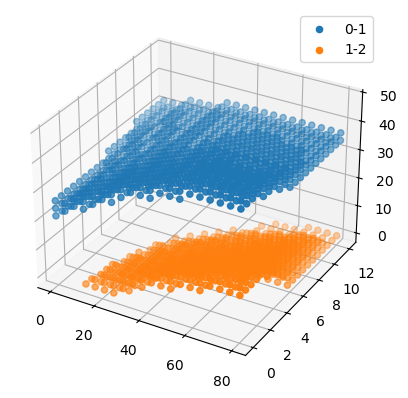

In [35]:
ds_result = xr.load_dataset("../benchmarking/v3.0/results_105_measurements_10162025/P0/0/ds.nc")
boundaries = find_boundary_points(
    ds_result.design_space_grid.to_numpy()[:,[0,2,1]], 
    ds_result.phase_mean.to_numpy(), 
    k=16
)

for key, val in boundaries.items():
    print(f"Boundary {key}: {len(val)} points")

fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
for key, points in boundaries.items():
    ax.scatter(
        points[:,0],
        points[:,1],
        points[:,2],
        label = "-".join(f"{k}" for k in key)
    )
ax.legend()
plt.show()

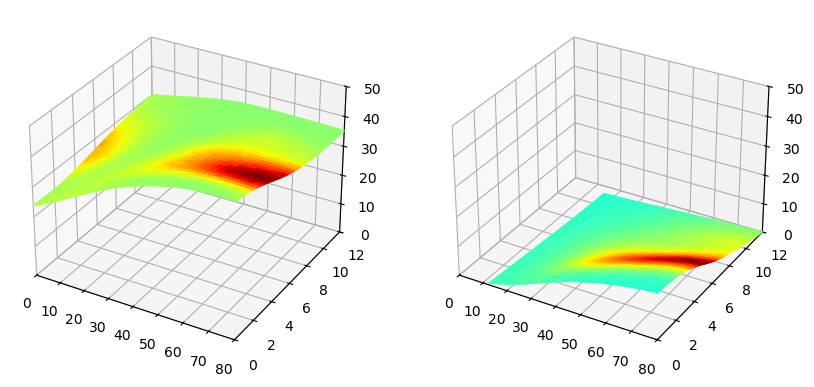

In [36]:
query_01 = PointCloudSurface(boundaries[(0,1)])
query_12 = PointCloudSurface(boundaries[(1,2)])
fig, axs = plt.subplots(
    1,2,
    figsize=(5*2, 5), 
    subplot_kw = {"projection":"3d"}
)
plot_surface(query_01, ax = axs[0])
plot_surface(query_12, ax = axs[1])
for ax in axs:
    ax.set_xlim([0.0, 80.0])
    ax.set_ylim([0.0, 12.0])
    ax.set_zlim([0.0, 50.0])
plt.show()

Boundary (0, 1): 1895 points
Boundary (1, 2): 1288 points


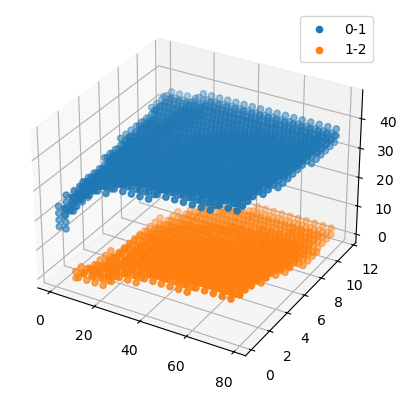

In [37]:
DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
boundary_dataset = xr.load_dataset(DIR+'/dataset/250610-extrap_expand_dataset.nc')
composition = boundary_dataset.composition
# Define per-component limits
limits = {'protein': (0.0, 80.0), 'glycerol': (0.0, 12.0), 'temperature': (0.0, 50.0)}
# Build a mask for each component
masks = []
for c in composition.component.values:
    min_val, max_val = limits[c]
    masks.append(
        (composition.sel(component=c) >= min_val) & (composition.sel(component=c) <= max_val)
    )
# Combine masks across components: keep only samples where ALL components satisfy their limits
combined_mask = xr.concat(masks, dim="component").all(dim="component")

# Select only the valid samples
xyz = composition.sel(sample=combined_mask)
ell = boundary_dataset.labels.sel(sample=combined_mask)
ref_boundaries = find_boundary_points(xyz.values.T[:,[0,2,1]], ell.values, k=16)

for key, val in ref_boundaries.items():
    print(f"Boundary {key}: {len(val)} points")

fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
for key, points in ref_boundaries.items():
    ax.scatter(
        points[:,0],
        points[:,1],
        points[:,2],
        label = "-".join(f"{k}" for k in key)
    )
ax.legend()
plt.show()

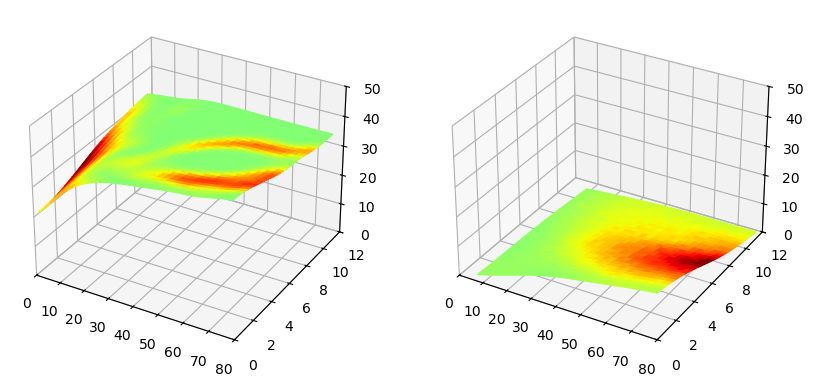

In [38]:
ref_01 = PointCloudSurface(ref_boundaries[(0,1)])
ref_12 = PointCloudSurface(ref_boundaries[(1,2)])
fig, axs = plt.subplots(
    1,2,
    figsize=(5*2, 5), 
    subplot_kw = {"projection":"3d"}
)
plot_surface(ref_01, ax = axs[0])
plot_surface(ref_12, ax = axs[1])
for ax in axs:
    ax.set_xlim([0.0, 80.0])
    ax.set_ylim([0.0, 12.0])
    ax.set_zlim([0.0, 50.0])
plt.show()

In [39]:
q = SRNF(query_01)
r = SRNF(ref_01)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define reparametrization-network
RN = SurfaceReparametrizer(
    [SineFourierLayer(10) for _ in range(10)]
).to(device)
loss_func = SurfaceDistance(q, r, k=32, h=1e-4).to(device)

optimizer = optim.LBFGS(RN.parameters(), max_iter=30, line_search_fn="strong_wolfe")
errors = reparametrize(RN, loss_func, optimizer, 30, Logger(1))
RN.to("cpu"), loss_func.to("cpu"); # Need on CPU for plotting.
RN.detach()


[Iter     1] loss: 141.991455
[Iter     2] loss: 140.729355
[Iter     3] loss: 140.793335
Finished training in 6.22658s


In [43]:
q = SRNF(query_12)
r = SRNF(ref_12)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define reparametrization-network
RN = SurfaceReparametrizer(
    [SineFourierLayer(10) for _ in range(10)]
).to(device)
loss_func = SurfaceDistance(q, r, k=32, h=1e-4).to(device)

optimizer = optim.LBFGS(RN.parameters(), max_iter=30, line_search_fn="strong_wolfe")
errors = reparametrize(RN, loss_func, optimizer, 30, Logger(1))
RN.to("cpu"), loss_func.to("cpu"); # Need on CPU for plotting.
RN.detach()


[Iter     1] loss: 65.372002
[Iter     2] loss: 64.093620
[Iter     3] loss: 60.903214
[Iter     4] loss: 60.903214
Finished training in 3.09487s


## Test function from evaluate.py

In [46]:
from evaluate import get_boundaries_geodesic_distance 

for _ in range(3):
    dists = get_boundaries_geodesic_distance(
        ds_result.design_space_grid, 
        ds_result.phase_mean
        )
    print(dists)

2025-10-16 14:35:00 - INFO - [evaluate.py] - Boundary (0, 1): 951 points
2025-10-16 14:35:00 - INFO - [evaluate.py] - Boundary (0, 1): 951 points
2025-10-16 14:35:00 - INFO - [evaluate.py] - Boundary (1, 2): 720 points
2025-10-16 14:35:00 - INFO - [evaluate.py] - Boundary (1, 2): 720 points
2025-10-16 14:35:00 - INFO - [evaluate.py] - Evaluating boundary (0, 1)
2025-10-16 14:35:00 - INFO - [evaluate.py] - Evaluating boundary (0, 1)
2025-10-16 14:35:06 - INFO - [evaluate.py] - Evaluating boundary (1, 2)
2025-10-16 14:35:06 - INFO - [evaluate.py] - Evaluating boundary (1, 2)
2025-10-16 14:35:15 - INFO - [evaluate.py] - Boundary (0, 1): 951 points
2025-10-16 14:35:15 - INFO - [evaluate.py] - Boundary (0, 1): 951 points
2025-10-16 14:35:15 - INFO - [evaluate.py] - Boundary (1, 2): 720 points
2025-10-16 14:35:15 - INFO - [evaluate.py] - Boundary (1, 2): 720 points
2025-10-16 14:35:15 - INFO - [evaluate.py] - Evaluating boundary (0, 1)
2025-10-16 14:35:15 - INFO - [evaluate.py] - Evaluating 

{(0, 1): 126.5295181274414, (1, 2): 52.599090576171875}


2025-10-16 14:35:27 - INFO - [evaluate.py] - Evaluating boundary (1, 2)
2025-10-16 14:35:27 - INFO - [evaluate.py] - Evaluating boundary (1, 2)
2025-10-16 14:35:36 - INFO - [evaluate.py] - Boundary (0, 1): 951 points
2025-10-16 14:35:36 - INFO - [evaluate.py] - Boundary (0, 1): 951 points
2025-10-16 14:35:36 - INFO - [evaluate.py] - Boundary (1, 2): 720 points
2025-10-16 14:35:36 - INFO - [evaluate.py] - Boundary (1, 2): 720 points
2025-10-16 14:35:36 - INFO - [evaluate.py] - Evaluating boundary (0, 1)
2025-10-16 14:35:36 - INFO - [evaluate.py] - Evaluating boundary (0, 1)


{(0, 1): 128.91221618652344, (1, 2): 52.599090576171875}


2025-10-16 14:35:48 - INFO - [evaluate.py] - Evaluating boundary (1, 2)
2025-10-16 14:35:48 - INFO - [evaluate.py] - Evaluating boundary (1, 2)


{(0, 1): 128.16494750976562, (1, 2): 52.599090576171875}
